# Acea Smart Water - Lake Bilacino

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importo mis datos en un dataframe

In [2]:
df = pd.read_csv('../data/raw/Lake_Bilancino.csv')

Obtengo 5 filas aleatorias para tener contexto

In [3]:
df.sample(5)

,Date,Rainfall_S_Piero,Rainfall_Mangona,Rainfall_S_Agata,Rainfall_Cavallina,Rainfall_Le_Croci,Temperature_Le_Croci,Lake_Level,Flow_Rate
1400,03/04/2006,0.0,8.8,2.8,0.4,2.0,15.25,251.98,2.1
5849,08/06/2018,0.0,0.0,0.0,0.0,0.0,19.35,251.92,0.6
2135,07/04/2008,0.0,0.0,0.0,0.0,0.0,10.70,249.52,0.6
3285,01/06/2011,2.8,2.0,2.4,2.8,3.2,20.50,251.08,0.6
1858,05/07/2007,0.0,0.0,0.0,0.0,0.0,18.05,250.62,2.0


Transformo mi columna Date en formato de fechas

In [4]:
from datetime import datetime, date 

df['Date'] = pd.to_datetime(df['Date'], format = '%d/%m/%Y')
df.head()

,Date,Rainfall_S_Piero,Rainfall_Mangona,Rainfall_S_Agata,Rainfall_Cavallina,Rainfall_Le_Croci,Temperature_Le_Croci,Lake_Level,Flow_Rate
0,2002-06-03,NaN,NaN,NaN,NaN,NaN,NaN,249.43,0.31
1,2002-06-04,NaN,NaN,NaN,NaN,NaN,NaN,249.43,0.31
2,2002-06-05,NaN,NaN,NaN,NaN,NaN,NaN,249.43,0.31
3,2002-06-06,NaN,NaN,NaN,NaN,NaN,NaN,249.43,0.31
4,2002-06-07,NaN,NaN,NaN,NaN,NaN,NaN,249.44,0.31


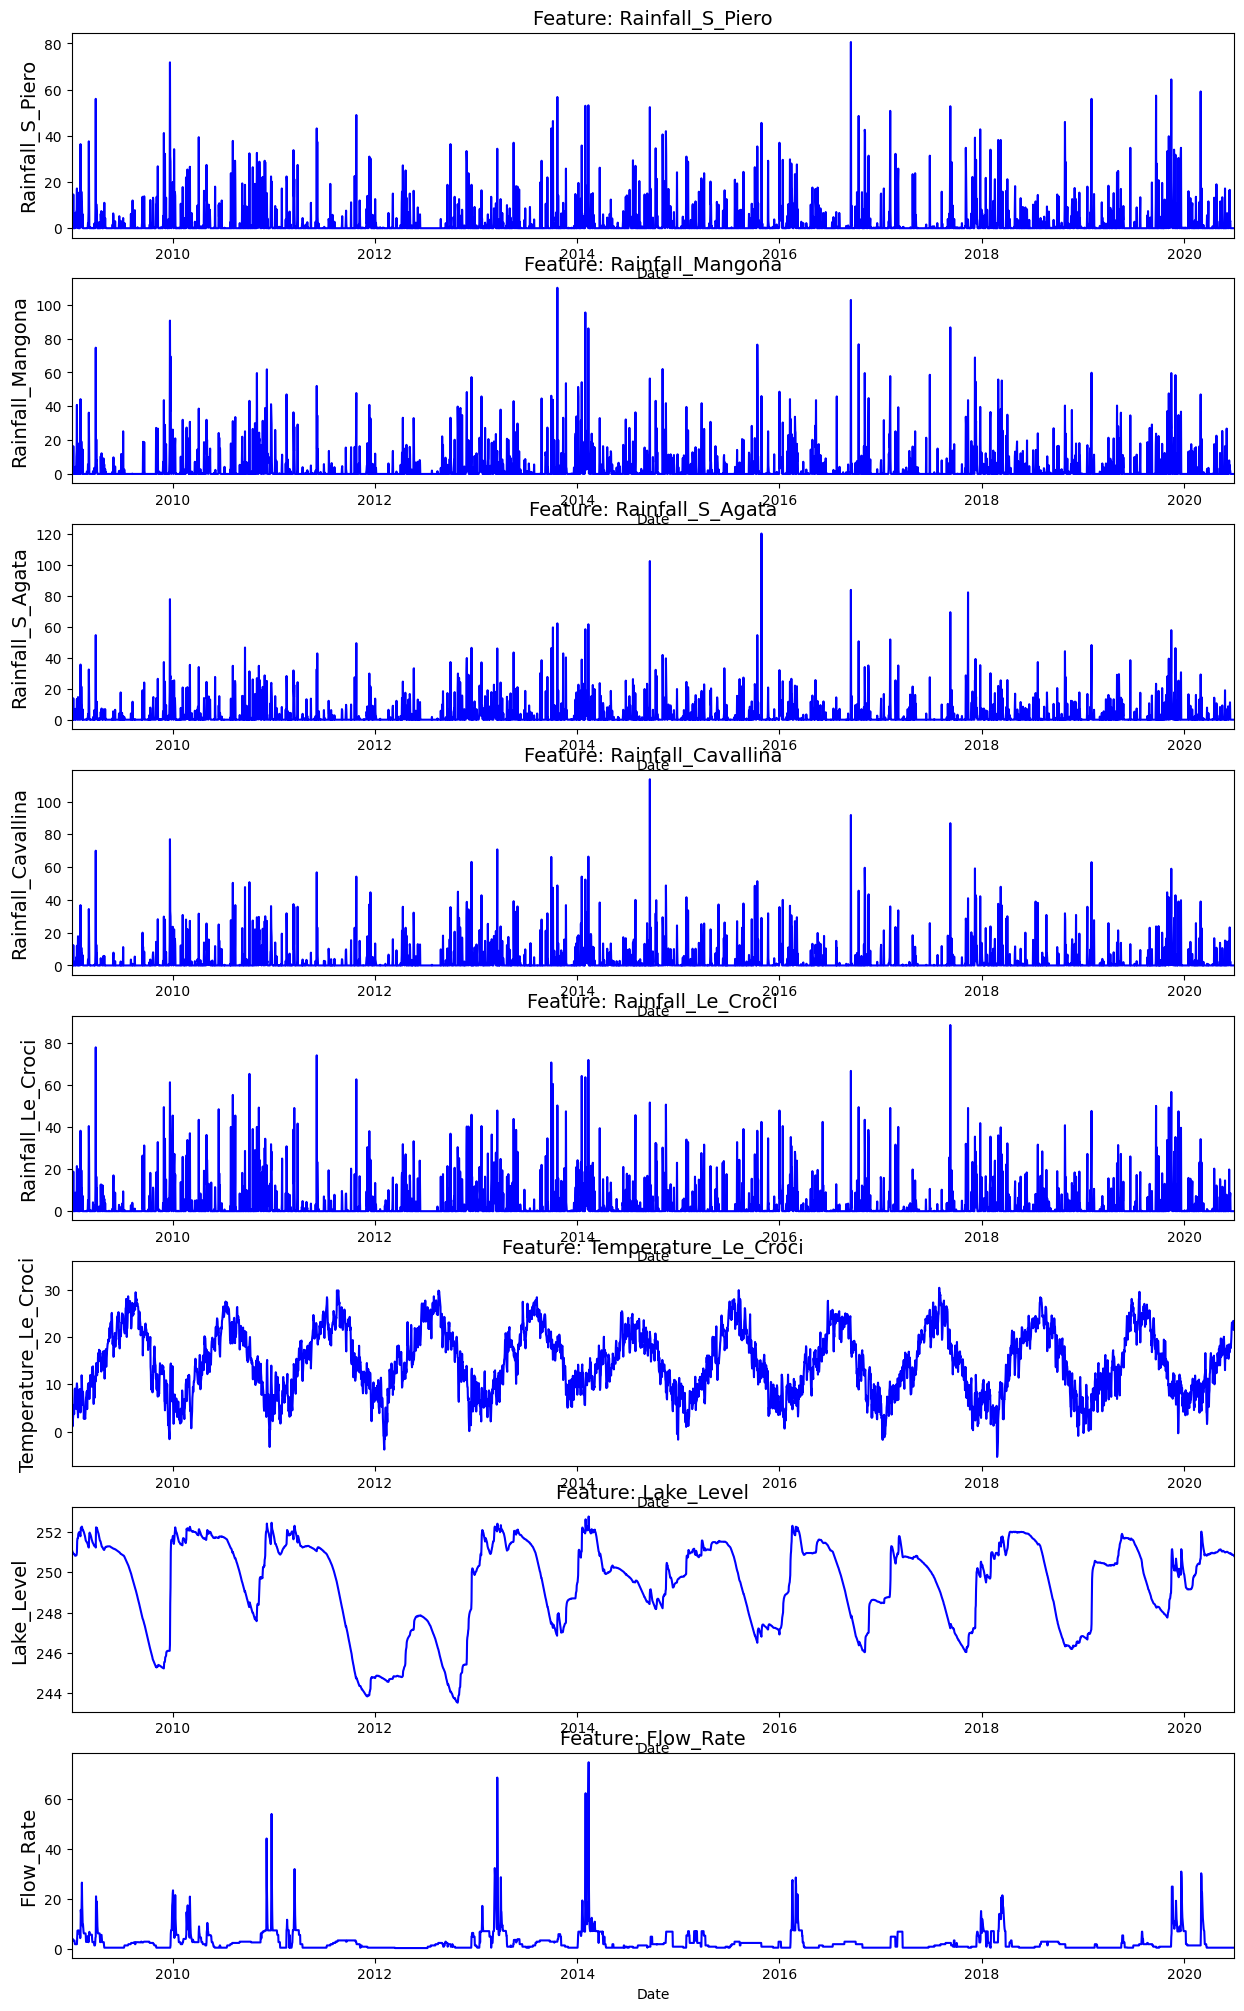

In [5]:
f, ax = plt.subplots(nrows=8, ncols=1, figsize=(15, 25))

for i, column in enumerate(df.drop('Date', axis=1).columns):
    sns.lineplot(x=df['Date'], y=df[column].ffill(), ax=ax[i], color='blue')
    ax[i].set_title('Feature: {}'.format(column), fontsize=14)
    ax[i].set_ylabel(ylabel=column, fontsize=14)
                      
    ax[i].set_xlim([date(2009, 1, 1), date(2020, 6, 30)])    

Antes de continuar, primero voy a asegurarme de que mis datos sigan una progresion diaria

In [6]:
diferencias = df['Date'].diff()
diferencias.max()

Timedelta('1 days 00:00:00')

Confirmo que mis datos son series temporales de 1 dia

Voy a tomar mis datos de Lake_Level y su desarrollo sobre el tiempo, intentare predecir el nivel del agua a lo largo del tiempo

In [7]:
df = df[['Date', 'Lake_Level']].copy()

Marco la columna de fechas como mi indice

In [8]:
df.set_index('Date', inplace=True)
df

,Lake_Level
Date,
2002-06-03,249.43
2002-06-04,249.43
2002-06-05,249.43
2002-06-06,249.43
2002-06-07,249.44
...,...
2020-06-26,250.85
2020-06-27,250.84
2020-06-28,250.83


Visualizo mis datos.

<Axes: xlabel='Date'>

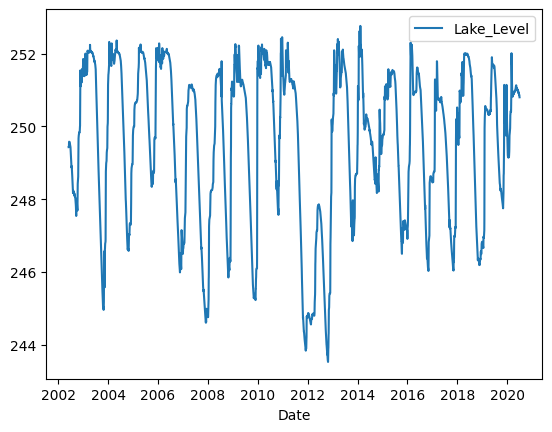

In [9]:
sns.lineplot(data = df)

## Decomposicion de la serie - Diaria

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df, period = 365) # Dado que he comprobado que son datos diarios usare un periodo diario

## Analisis de tendencia

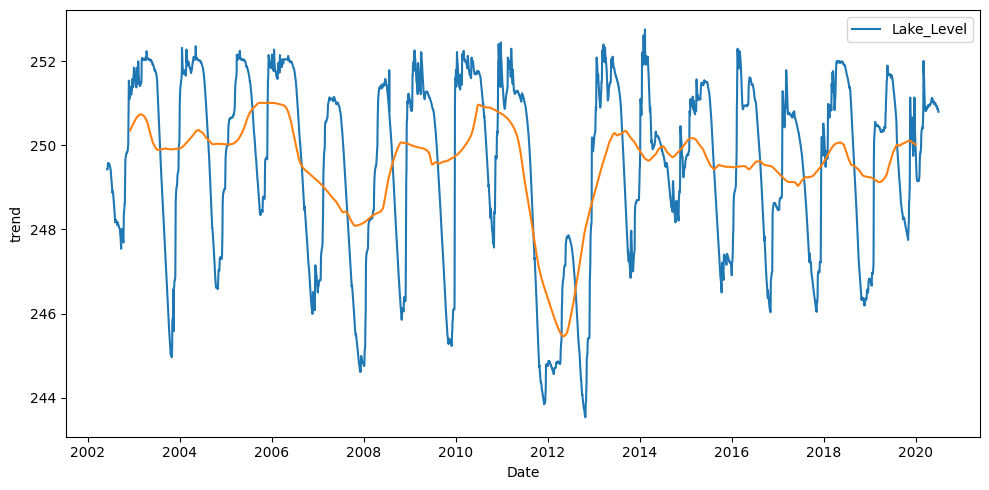

In [11]:
trend = decomposition.trend

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = trend)


plt.tight_layout()

plt.show()

## Analisis de estacionalidad

In [12]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(df)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -6.880991e+00
p-value                        1.433634e-09
#Lags Used                     3.500000e+01
Number of Observations Used    6.567000e+03
Critical Value (1%)           -3.431346e+00
Critical Value (5%)           -2.861980e+00
Critical Value (10%)          -2.567004e+00
dtype: float64

Esto me confirma que mis datos son estacionales, ya que mi prueba Dickey-Fuller me indica que el p-value es menor de 0.05, confirmando esto la hipotesis de que mis datos son estacionales

## Analisis de variabilidad

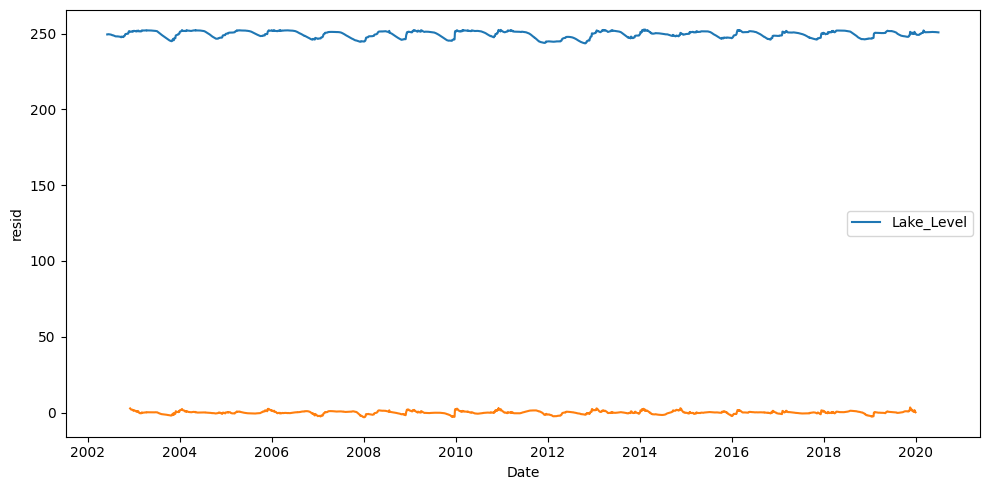

In [13]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = residual)

plt.tight_layout()

plt.show()

## Analisis de autocorrelacion

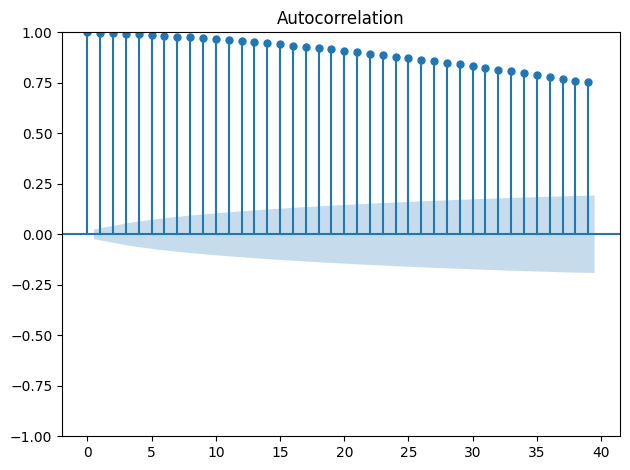

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df)

plt.tight_layout()

plt.show()

Se puede observar una alta correlacion que disminuye sobre el tiempo, pero manteniendose alta

## Entrenamiento del modelo

In [15]:
from pmdarima import auto_arima

model = auto_arima(df['Lake_Level'], seasonal=True, m=365, trace=True, error_action='ignore', suppress_warnings=True)

c:\Users\Carlos\anaconda3\envs\geeks\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Carlos\anaconda3\envs\geeks\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Carlos\anaconda3\envs\geeks\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Carlos\anaconda3\envs\geeks\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Carlos\anaconda3\envs\geeks\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in

Performing stepwise search to minimize aic


KeyboardInterrupt: 

## Prediccion del modelo

In [ ]:
forecast = model.predict(365) # Predecimos una año completo

In [ ]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df)
sns.lineplot(data = forecast, c = "green")

plt.tight_layout()

plt.show()